# Применение простых моделей для решения задачи

Требуется:
1. Выбрать ключевую метрику для оценки качества моделей
2. Применить простые модели машинного обучения
3. Оценить качество обученных моделей
4. Подобрать гиперпараметры моделей
5. Написать выводы

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, NuSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [ ]:
PROJECT_ROOT = Path.cwd()
RAW_PATH = PROJECT_ROOT / "raw_posts_labeled.csv"

RANDOM_STATE = 42

### Подготовим данные

In [27]:
def clean_text(text: str) -> str:
    """
    Простая очистка текста:
      - убираем ссылки, @упоминания, #хэштеги
      - приводим к нижнему регистру
      - выкидываем цифры, лишние символы и пунктуацию
      - схлопываем лишние пробелы
    """
    URL_RE = re.compile(r"http\S+|www\.\S+|t\.me/\S+")
    MENTION_RE = re.compile(r"@\w+")
    HASHTAG_RE = re.compile(r"#\w+")
    NON_LETTERS_RE = re.compile(r"[^a-zA-Zа-яА-ЯёЁ\s]")

    if not isinstance(text, str):
        return ""

    # нижний регистр
    t = text.lower()

    # ссылки, упоминания, хэштеги
    t = URL_RE.sub(" ", t)
    t = MENTION_RE.sub(" ", t)
    t = HASHTAG_RE.sub(" ", t)

    # убираем всё, кроме букв и пробелов
    t = NON_LETTERS_RE.sub(" ", t)

    # схлопываем пробелы
    t = re.sub(r"\s+", " ", t).strip()

    return t

In [28]:
def preprocess_data(file_path, min_len: int = 10):
    """
    Загружаем сырой датасет → чистим тексты → фильтруем совсем короткие →
    сохраняем processed_posts.csv
    """
    if not file_path.exists():
        raise FileNotFoundError(f"Не найден файл {file_path}")

    print(f"[*] Загружаем сырой датасет: {file_path}")
    df = pd.read_csv(file_path)

    # Проверим, что нужные колонки есть
    if "text" not in df.columns:
        raise ValueError("В '{file_path}' нет колонки 'text'")

    df = df.dropna(subset=["text"])
    df = df[df["text"].astype(str).str.strip() != ""]

    print(f"[*] Строк после удаления пустых текстов: {len(df)}")

    print("[*] Очищаем тексты...")
    df["text_clean"] = df["text"].astype(str).apply(clean_text)

    # Фильтруем слишком короткие очищенные тексты
    before_len = len(df)
    df = df[df["text_clean"].str.len() >= min_len]
    print(f"[*] Убрали слишком короткие тексты: {before_len} → {len(df)}")

    df = df.drop_duplicates(subset=["text_clean", "topic"], keep="first")

    # Сохраняем только нужные колонки
    keep_cols = []
    for col in ["id", "date", "channel", "topic", "text", "text_clean"]:
        if col in df.columns:
            keep_cols.append(col)
    df = df[keep_cols]
    return df

In [29]:
df = preprocess_data(RAW_PATH, min_len=15) 
print(f"\nРазмер датасета: {df.shape[0]} строк")
print(f"Колонки: {list(df.columns)}")

[*] Загружаем сырой датасет: /home/maleksyuk/HSE/aggregator-bot/ML/raw_posts_labeled.csv
[*] Строк после удаления пустых текстов: 262
[*] Очищаем тексты...
[*] Убрали слишком короткие тексты: 262 → 258

Размер датасета: 257 строк
Колонки: ['date', 'topic', 'text', 'text_clean']


In [30]:
df.head()

,date,topic,text,text_clean
0,2025-11-01T18:01:06+00:00,3,Главные новости к вечеру Правительство утверди...,главные новости к вечеру правительство утверди...
1,2025-11-01T17:34:42+00:00,3,Атомная подводная лодка «Хабаровск» спущена на...,атомная подводная лодка хабаровск спущена на в...
2,2025-11-01T17:14:39+00:00,4,Онлайн-банк Revolut начал блокировать счета ро...,онлайн банк revolut начал блокировать счета ро...
3,2025-11-01T16:24:55+00:00,3,"Образование, ЖКХ, здравоохранение и туризм дол...",образование жкх здравоохранение и туризм должн...
4,2025-11-01T16:09:31+00:00,3,Премьер-министр Венгрии Виктор Обран назвал во...,премьер министр венгрии виктор обран назвал во...


In [ ]:
X_data = df["text_clean"]
y_data = df["topic"]

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=RANDOM_STATE)

### Выберем основную метрику

In [32]:
class_counts = pd.Series(y_train).value_counts()
print("Распределение классов:")
print(class_counts)
print(f"\nВсего классов: {len(class_counts)}")

Распределение классов:
topic
3     43
10    27
6     18
4     17
0     17
1     15
5     12
7     11
2      9
9      5
8      5
Name: count, dtype: int64

Всего классов: 11


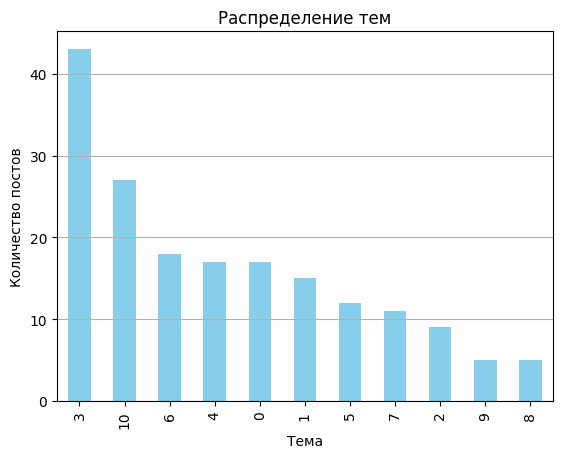

In [33]:
class_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение тем')
plt.xlabel('Тема')
plt.ylabel('Количество постов')
plt.grid(axis='y')
plt.show()

In [34]:
print(f"Медианный размер класса: {class_counts.median():.2f}")
print(f"Минимальный размер: {class_counts.min()}")
print(f"Максимальный размер: {class_counts.max()}")
print(f"Стандартное отклонение: {class_counts.std():.2f}")
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Коэффициент дисбаланса: {imbalance_ratio:.2f}")

Медианный размер класса: 15.00
Минимальный размер: 5
Максимальный размер: 43
Стандартное отклонение: 10.90
Коэффициент дисбаланса: 8.60


Частота целевых значений имеет большой разброс. Будем считать, что значимость каждой тематики одинакова. Выбираем метрику f1 как среднее между точностью и полнотой. Чтобы не выделять значимость каждой отдельной темы будем делать макро-усреднение.

В качестве основной метрики выбираем f1 macro

Источники:
1. Курс на Stepik: https://stepik.org/lesson/856948?auth=login&unit=860947
2. Статья с разбором метрик: https://towardsdatascience.com/micro-macro-weighted-averages-of-f1-score-clearly-explained-b603420b292f/

### Обучим модели и оценим их качество

1. Обучим модели с параметрами по умолчанию
2. Подберём гиперпараметры по GridSearchCV
3. Выведем таблицы с метриками для полученных моделей

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),    # 1-2 граммы
    min_df=5,              # слово должно встретиться минимум в 5 документах
    max_features=20000,    # максимум 20к признаков
)
tfidf.fit(X_train)
X_train = tfidf.transform(X_train)
X_test = tfidf.transform(X_test)

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print(f"[*] Найденные классы ({len(le.classes_)}): {list(le.classes_)}")
print(f"[*] Распределение классов в train (закодировано):")
unique, counts = np.unique(y_train, return_counts=True)
for cls_idx, count in zip(unique, counts):
    cls_name = le.inverse_transform([cls_idx])[0]
    print(f"    {cls_name} (idx={cls_idx}): {count} примеров")

[*] Найденные классы (11): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[*] Распределение классов в train (закодировано):
    0 (idx=0): 17 примеров
    1 (idx=1): 15 примеров
    2 (idx=2): 9 примеров
    3 (idx=3): 43 примеров
    4 (idx=4): 17 примеров
    5 (idx=5): 12 примеров
    6 (idx=6): 18 примеров
    7 (idx=7): 11 примеров
    8 (idx=8): 5 примеров
    9 (idx=9): 5 примеров
    10 (idx=10): 27 примеров


In [63]:
def calc_metrics(y_true, y_pred):
    metric_macro = lambda f, **kwargs: f(y_true, y_pred, average="macro", **kwargs)
    return {
        "f1_macro": metric_macro(f1_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": metric_macro(precision_score, zero_division=0),
        "recall_macro": metric_macro(recall_score, zero_division=0)
    }

def print_metrics(metric_names, result):
    return pd.DataFrame(result).T

metric_names = [
    "f1_macro",
    "accuracy", 
    "precision_macro",
    "recall_macro"
]

In [51]:
models = [
    ("LogReg-ovr", LogisticRegression(multi_class='ovr'), {
        'C': [0.01, 0.1, 0.5, 1, 10, 100]
    }),
    ("LogReg-multinomial", LogisticRegression(multi_class='multinomial'), {
        'C': [0.01, 0.1, 0.5, 1, 10, 100]
    }),
    ("SGDClassifier", SGDClassifier(), {
        'alpha': [0.01, 0.1, 0.5, 1, 10],
        'l1_ratio': [0.01, 0.1, 0.15, 0.5, 1]
    }),
    ("LinearSVC", LinearSVC(), {
        'C': [0.01, 0.1, 0.5, 1, 10, 100]
    }),
    ("RidgeClassifier", RidgeClassifier(), {
        'alpha': [0.01, 0.1, 0.5, 1, 10]
    }),
    ("MultinomialNB", MultinomialNB(), {
        'alpha': [0.01, 0.1, 0.5, 1, 10]
    }),
    ("KNN_k11", KNeighborsClassifier(n_neighbors=11), {
        'p': [0.5, 1, 1.5, 2, 5]
    }),
    ("NuSVC", NuSVC(nu=0.1), {
        'nu': [0.01, 0.05, 0.1, 0.2],
        'degree': [1, 2, 3],
        'coef0': [0, 0.01, .1, .5, 1, 10],
        'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
    })
]

In [ ]:
scoring = 'f1_macro'
# scoring = 'accuracy'
# scoring = 'precision'
# scoring = 'recall_macro'

gs_list = []

for name, model, params in models:
    print(name)
    gs = GridSearchCV(model, params, cv=5, scoring=scoring)
    gs.fit(X_train, y_train)
    gs_list.append(gs)
    print(gs.best_params_)
    print()

LogReg-ovr


{'C': 100}

LogReg-multinomial
{'C': 10}

SGDClassifier
{'alpha': 0.01, 'l1_ratio': 0.5}

LinearSVC
{'C': 1}

RidgeClassifier
{'alpha': 0.5}

MultinomialNB
{'alpha': 0.1}

KNN_k11
{'p': 2}

NuSVC
{'coef0': 0.1, 'degree': 1, 'kernel': 'sigmoid', 'nu': 0.01}



In [ ]:
print('Модели с параметрами по умолчанию')

result = {}
for name, model, _ in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    result[name] = calc_metrics(y_test, y_pred)

df_models_default = print_metrics(metric_names, result)
df_models_default.sort_values('f1_macro', ascending=False)

Модели без подбора


,f1_macro,accuracy,precision_macro,recall_macro
LinearSVC,0.275824,0.397436,0.332984,0.269430
RidgeClassifier,0.269776,0.410256,0.348701,0.258445
NuSVC,0.255947,0.435897,0.362558,0.254657
SGDClassifier,0.255150,0.358974,0.318561,0.235339
KNN_k11,0.245087,0.320513,0.331385,0.249510
LogReg-multinomial,0.143226,0.346154,0.249874,0.169657
LogReg-ovr,0.118776,0.320513,0.149145,0.156324
MultinomialNB,0.116667,0.333333,0.200361,0.159240


In [ ]:
print('Модели, подобранные GridSearchCV')

result_gs = {}
for model_tuple, gs in zip(models, gs_list):
    name, _, _ = model_tuple
    model = gs.best_estimator_
    y_pred = model.predict(X_test)
    result_gs[name] = calc_metrics(y_test, y_pred)

df_models_gs = print_metrics(metric_names, result_gs)
df_models_gs.sort_values('f1_macro', ascending=False)

Модели, подобранные GridSearchCV


,f1_macro,accuracy,precision_macro,recall_macro
MultinomialNB,0.292171,0.397436,0.402500,0.280907
LinearSVC,0.275824,0.397436,0.332984,0.269430
LogReg-ovr,0.266693,0.384615,0.319066,0.263748
RidgeClassifier,0.256783,0.397436,0.273647,0.252763
SGDClassifier,0.246866,0.397436,0.276166,0.250958
KNN_k11,0.245087,0.320513,0.331385,0.249510
LogReg-multinomial,0.221912,0.358974,0.247054,0.228097
NuSVC,0.216697,0.307692,0.246843,0.204813


# Выводы

В работе был рассмотрен набор данных, полученный на предыдущем этапе в результате парсинга Телеграмм-каналов. После очистки тексты преобразуются в вектора с помощью TF-IDF. В файле имеется 11 категорий, каждая из которых закодирована числом.

В качестве основной метрики качества моделей была выбрана метрика **f1 macro**, поскольку допускаем равную значимость каждого класса.

Среди рассмотренных моделей с параметрами по умолчанию лучший показатель метрики **f1** имеет модель **LinearSVC** (0.28). В результате перебора гиперпараметров улучшилась метрика модели **MultinomialNB** (с 0.12 до 0.29), получив лучшее значение **f1**, а качество **LinearSVC** не изменилось.